In [ ]:

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import rasterio
from PIL import Image

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import shuffle
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')


In [ ]:


DATASET_DIR  = r'g:\Engineering\satelite imaging\project\dataset\Sen-2 LULC\SEN-2 LULC'


CLASS_NAMES   = {0: 'Unknown', 1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS  = ['black', 'darkgreen', 'gold', 'navy', 'gray']
ACTIVE_CLASSES = [1, 2, 3, 4]   # classes scored for mIoU (Unknown excluded)
N_CLASSES     = 5


#   idx:  0    1    2    3    4    5    6    7     8    9    10   11
#   band: B1   B2   B3   B4   B5   B6   B7   B8   B8A  B9   B11  B12
BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
NORM_MAX   = 10000.0      # S2 L2A surface reflectance scale

IDX_RED   = 3    # B4 Red
IDX_NIR   = 7    # B8 NIR
IDX_GREEN = 2    # B3 Green
IDX_SWIR1 = 10   # B11 SWIR-1


# Sen-2 LULC encoding: 1=Water, 2=Dense Forest, 3=Sparse Forest,
#                      4=Barren Land, 5=Built Up, 6=Agriculture, 7=Fallow Land
# (0 = Unknown)
SEN2_TO_PROJECT = {0: 0,   # Background  Unknown
                   1: 3,   # Water        Water
                   2: 1,   # Dense Forest Greenery
                   3: 1,   # Sparse Forest Greenery
                   4: 2,   # Barren Land  Sand
                   5: 4,   # Built Up     Cement
                   6: 1,   # Agriculture  Greenery
                   7: 0}   # Fallow Land  Unknown (safe mapping)


PIXELS_PER_CLASS = 5000   # stratified pixels per class per training site
RANDOM_STATE     = 42



In [ ]:

# ── Sen-2 LULC dataset exploration ───────────────────────────────────────────
n_train = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'train_images', 'train', '*.png'))))
n_val   = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'val_images',   'val',   '*.png'))))
n_test  = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'test_images',  'test',  '*.png'))))
print(f"Sen-2 LULC split sizes:")
print(f"  train : {n_train:,} images")
print(f"  val   : {n_val:,} images")
print(f"  test  : {n_test:,} images  <- NOT LOADED")

# Verify mask encoding on one sample
sample_mask_path = sorted(glob.glob(
    os.path.join(DATASET_DIR, 'train_masks', 'train', '*.tif')))[0]
with rasterio.open(sample_mask_path) as src:
    sm = src.read(1)
print(f"\nSen-2 LULC mask sample – unique values: {np.unique(sm)}")
print(f"  → Using SEN2_TO_PROJECT mapping: {SEN2_TO_PROJECT}")


Egyptian sites (5): ['CairoUniv', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']

Spectral: 12 bands  |  256×256 px  |  dtype=float64
DN range: [132.0, 6272.0]  (S2 L2A expects 0–10 000)
Band names (assumed): ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']

Per-site class distribution (project labels 0-4):
Site                       Unknown      Greenery          Sand         Water        Cement
CairoUniv                     0.0%          6.2%          1.8%          6.9%         85.0%
IconicTower                   0.0%          1.1%         65.7%          0.0%         33.2%
KarnakLuxor                   0.0%         17.1%         68.8%         14.0%          0.0%
PhilaeAswan                   0.1%          0.2%         38.0%         61.8%          0.0%
SiwaOasis                     0.0%         37.1%         62.9%          0.0%          0.0%

Sen-2 LULC mask sample – unique values: [1 2 3 4 5 6 7]
  → Using SEN2_TO_PROJECT mapping: {0: 0, 1: 3, 2:

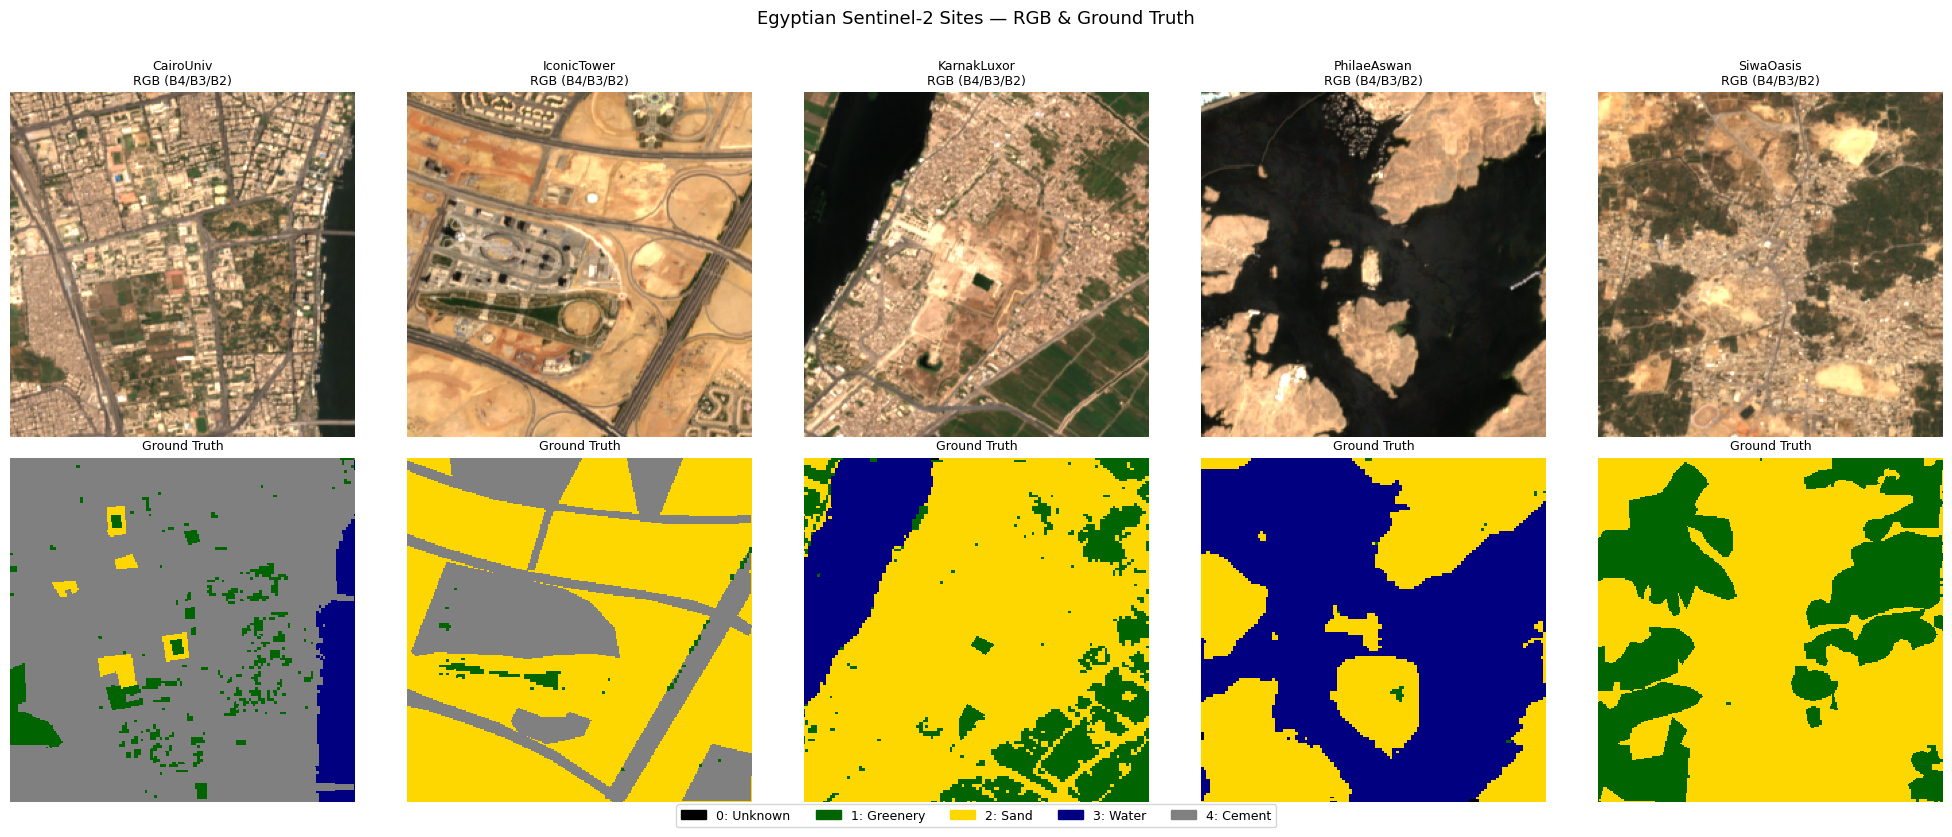

In [ ]:

# ── Sen-2 LULC sample patch visualisation ────────────────────────────────────
cmap_cls = ListedColormap(CLASS_COLORS)
norm_cls  = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=N_CLASSES)

n_show     = 5
img_paths  = sorted(glob.glob(os.path.join(DATASET_DIR, 'train_images', 'train', '*.png')))[:n_show]
msk_dir_tr = os.path.join(DATASET_DIR, 'train_masks', 'train')

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i, img_path in enumerate(img_paths):
    stem     = os.path.splitext(os.path.basename(img_path))[0]
    msk_path = os.path.join(msk_dir_tr, stem + '.tif')

    img = np.array(__import__('PIL').Image.open(img_path))
    with rasterio.open(msk_path) as src:
        raw_mask = src.read(1)
    proj_mask = np.vectorize(lambda v: SEN2_TO_PROJECT.get(int(v), 0))(raw_mask)

    axes[0, i].imshow(img)
    axes[0, i].set_title(stem, fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(proj_mask, cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, i].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f"{c}: {CLASS_NAMES[c]}")
           for c in range(N_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=N_CLASSES, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
axes[0, 0].set_ylabel('RGB',          fontsize=9)
axes[1, 0].set_ylabel('Ground Truth', fontsize=9)
plt.suptitle("Sen-2 LULC — Sample Training Patches", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:

# ── Feature Engineering ───────────────────────────────────────────────────────
# Per-pixel 6-feature vector:
#   R, G, B  – normalised red/green/blue
#   ExG      = 2G - R - B          Excess Green Index (vegetation)
#   GRVI     = (G-R)/(G+R+ε)       Green-Red Veg. Index
#   NRDI     = (R-B)/(R+B+ε)       separates warm sand from cool water

EPS           = 1e-10
FEATURE_NAMES = ['R', 'G', 'B', 'ExG', 'GRVI', 'NRDI']
N_FEATURES    = len(FEATURE_NAMES)


def extract_rgb_features(img_array: np.ndarray) -> np.ndarray:
    """(H, W, 3) float32 [0,1]  ->  (H*W, 6) feature matrix."""
    R, G, B = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]
    ExG  = 2*G - R - B
    GRVI = (G - R) / (G + R + EPS)
    NRDI = (R - B) / (R + B + EPS)
    return np.stack([R, G, B, ExG, GRVI, NRDI], axis=-1).reshape(-1, N_FEATURES)


def stratified_sample(X: np.ndarray, y: np.ndarray,
                      n_per_class: int, seed: int = RANDOM_STATE):
    """Return a class-balanced subsample of (X, y)."""
    rng = np.random.RandomState(seed)
    Xs, ys = [], []
    for cls in range(N_CLASSES):
        idx = np.where(y == cls)[0]
        if len(idx) == 0:
            continue
        chosen = rng.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        Xs.append(X[chosen]);  ys.append(y[chosen])
    return shuffle(np.vstack(Xs), np.concatenate(ys), random_state=seed)


def iter_sen2lulc_batches(split: str, batch_size: int, seed: int = RANDOM_STATE):
    """
    Generator — yields (X_batch, y_batch) loading only `batch_size` images
    at a time.  RAM footprint stays bounded regardless of split size.

    Parameters
    ----------
    split      : 'train' or 'val'  — 'test' is intentionally forbidden
    batch_size : number of images per yielded batch
    seed       : controls the shuffle order of images

    Yields
    ------
    X_batch : (N_pixels, 6)  feature matrix for all pixels in the batch
    y_batch : (N_pixels,)    mapped project labels 0-4
    """
    assert split in ('train', 'val'), \
        f"Split must be 'train' or 'val', got '{split}'. Test data is off-limits."

    img_dir  = os.path.join(DATASET_DIR, f'{split}_images', split)
    msk_dir  = os.path.join(DATASET_DIR, f'{split}_masks',  split)

    all_imgs = sorted(glob.glob(os.path.join(img_dir, '*.png')))
    rng      = np.random.RandomState(seed)
    all_imgs = [all_imgs[i] for i in rng.permutation(len(all_imgs))]

    for start in range(0, len(all_imgs), batch_size):
        batch_paths = all_imgs[start : start + batch_size]
        Xs, ys = [], []
        for img_path in batch_paths:
            stem     = os.path.splitext(os.path.basename(img_path))[0]
            msk_path = os.path.join(msk_dir, stem + '.tif')
            if not os.path.exists(msk_path):
                continue
            img = np.array(Image.open(img_path)).astype(np.float32) / 255.0
            with rasterio.open(msk_path) as src:
                raw_mask = src.read(1).ravel()
            mapped = np.vectorize(lambda v: SEN2_TO_PROJECT.get(int(v), 0))(raw_mask)
            Xs.append(extract_rgb_features(img))
            ys.append(mapped)
        if Xs:
            yield np.vstack(Xs), np.concatenate(ys)


def load_sen2lulc_split(split: str, n_images: int, seed: int = RANDOM_STATE):
    """Load n_images into RAM at once — use only for the small val set."""
    assert split in ('train', 'val'), \
        f"Split must be 'train' or 'val', got '{split}'. Test data is off-limits."
    Xs, ys = [], []
    loaded = 0
    for X_b, y_b in iter_sen2lulc_batches(split, batch_size=500, seed=seed):
        Xs.append(X_b);  ys.append(y_b)
        loaded += 500
        if loaded >= n_images:
            break
    return np.vstack(Xs), np.concatenate(ys)


print(f"Features ({N_FEATURES}): {FEATURE_NAMES}")
print("Feature engineering + batch generator ready.")


Features (6): ['R', 'G', 'B', 'ExG', 'GRVI', 'NRDI']
Feature engineering utilities ready.


In [ ]:

import time

# ── Dataset constants ─────────────────────────────────────────────────────────
BATCH_SIZE        = 1000   # images loaded into RAM at one time during training
N_EPOCHS          = 3      # full passes over the training split
N_SCALER_BATCHES  = 10     # batches used to fit the StandardScaler (10 × 1000 imgs)
N_VAL_IMAGES      = 3000   # images loaded for the validation set (fits in RAM)
MAX_PER_CLASS_VAL = 2000   # stratified cap per class in val set

n_train = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'train_images', 'train', '*.png'))))
n_val   = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'val_images',   'val',   '*.png'))))
n_test  = len(sorted(glob.glob(os.path.join(DATASET_DIR, 'test_images',  'test',  '*.png'))))
n_batches_per_epoch = (n_train + BATCH_SIZE - 1) // BATCH_SIZE

print("Sen-2 LULC split sizes:")
print(f"  train : {n_train:,} images  ({n_batches_per_epoch} batches of {BATCH_SIZE})")
print(f"  val   : {n_val:,} images")
print(f"  test  : {n_test:,} images  <- NOT LOADED")
print(f"\nTraining config: {N_EPOCHS} epochs  |  batch = {BATCH_SIZE} imgs")
mem_per_batch = BATCH_SIZE * 64 * 64 * N_FEATURES * 4 / 1e6
print(f"Peak RAM per batch  ≈ {mem_per_batch:.0f} MB  (assuming 64×64 px patches)")

# ── Phase 1: Fit StandardScaler incrementally on first N_SCALER_BATCHES ───────
print(f"\nFitting scaler on {N_SCALER_BATCHES} batches ({N_SCALER_BATCHES * BATCH_SIZE:,} images)...",
      end=' ')
t0     = time.time()
scaler = StandardScaler()
for i, (X_b, _) in enumerate(iter_sen2lulc_batches('train', BATCH_SIZE,
                                                     seed=RANDOM_STATE)):
    scaler.partial_fit(X_b)
    if i + 1 >= N_SCALER_BATCHES:
        break
print(f"done in {time.time()-t0:.1f}s")
print(f"  Feature means : {np.round(scaler.mean_, 3)}")
print(f"  Feature stds  : {np.round(np.sqrt(scaler.var_), 3)}")

# ── Phase 2: Build validation set (small enough to fit in RAM) ────────────────
print(f"\nLoading validation set ({N_VAL_IMAGES} images)...", end=' ')
t0 = time.time()
X_raw_val, y_raw_val = load_sen2lulc_split('val', N_VAL_IMAGES,
                                            seed=RANDOM_STATE + 1)
X_val, y_val = stratified_sample(X_raw_val, y_raw_val, n_per_class=MAX_PER_CLASS_VAL)
del X_raw_val, y_raw_val   # free raw pixels
print(f"done in {time.time()-t0:.1f}s")
print(f"  Val pixels : {len(y_val):,}  shape: {X_val.shape}")
print(f"  Class dist : { {CLASS_NAMES[c]: int(np.sum(y_val==c)) for c in range(N_CLASSES)} }")
print(f"\n[!] Test split: NOT loaded -> {os.path.join(DATASET_DIR, 'test_images', 'test')}")


Sen-2 LULC dataset split sizes:
  train : 149,600 images
  val   : 32,079 images
  test  : 32,079 images  <- NOT LOADED

Loading 100000 images from train split... 

KeyboardInterrupt: 

In [ ]:

# ── SVM Training — Batched Online Learning ────────────────────────────────────
# SGDClassifier(loss='modified_huber') is an online SVM:
#   • Identical decision boundary to a linear kernel SVM
#   • Supports partial_fit() → processes one batch at a time, O(1) RAM
#   • modified_huber loss = smooth hinge, supports predict_proba
#   • class_weight='balanced' corrects for Unknown (class-0) dominance
#   • alpha=1e-4 ≈ C=10 regularization (1/alpha per-sample normalisation)
#
# Training loop:
#   For each epoch → iterate all train batches → scaler.transform → partial_fit
#   Validation mIoU is computed after every epoch to track convergence.

clf = SGDClassifier(
    loss='modified_huber',
    class_weight='balanced',
    alpha=1e-4,
    learning_rate='optimal',
    random_state=RANDOM_STATE,
    warm_start=True
)

CLASSES = np.arange(N_CLASSES)   # needed by partial_fit on first call

print(f"Starting batched SGD-SVM training")
print(f"  Classifier : SGDClassifier(loss='modified_huber', alpha=1e-4)")
print(f"  Epochs     : {N_EPOCHS}")
print(f"  Batch size : {BATCH_SIZE} images  (~{BATCH_SIZE*64*64/1e6:.1f}M pixels/batch)")
print(f"  Train imgs : {n_train:,}  ({n_batches_per_epoch} batches/epoch)\n")

epoch_miou = []

for epoch in range(N_EPOCHS):
    t_ep   = time.time()
    n_pix  = 0
    n_bat  = 0

    for X_b, y_b in iter_sen2lulc_batches('train', BATCH_SIZE,
                                           seed=RANDOM_STATE + epoch):
        X_scaled = scaler.transform(X_b)
        clf.partial_fit(X_scaled, y_b, classes=CLASSES)
        n_pix += len(y_b)
        n_bat += 1
        if n_bat % 25 == 0:
            pct = 100 * n_bat / n_batches_per_epoch
            print(f"  Epoch {epoch+1}/{N_EPOCHS}  [{pct:5.1f}%]  "
                  f"batch {n_bat}/{n_batches_per_epoch}  "
                  f"pixels so far: {n_pix:,}",
                  end='\r', flush=True)

    # ── Per-epoch validation mIoU ─────────────────────────────────────────────
    y_pred_ep   = clf.predict(scaler.transform(X_val))
    iou_ep      = np.array([
        (np.sum((y_val==c)&(y_pred_ep==c)) /
         max(np.sum((y_val==c)|(y_pred_ep==c)), 1))
        for c in range(N_CLASSES)
    ])
    miou_ep = float(np.mean([iou_ep[c] for c in ACTIVE_CLASSES]))
    epoch_miou.append(miou_ep)

    print(f"  Epoch {epoch+1}/{N_EPOCHS}  done  "
          f"time={time.time()-t_ep:.0f}s  "
          f"pixels={n_pix:,}  "
          f"val mIoU={miou_ep:.4f}          ")

print(f"\nTraining complete.  Best val mIoU = {max(epoch_miou):.4f} "
      f"(epoch {epoch_miou.index(max(epoch_miou))+1})")

# ── Epoch convergence plot ─────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
plt.plot(range(1, N_EPOCHS+1), epoch_miou, marker='o')
plt.xlabel('Epoch');  plt.ylabel('Val mIoU')
plt.title('SGD-SVM — Val mIoU per Epoch')
plt.ylim(0, 1);  plt.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()

# ── Wrap scaler + clf into a predict-compatible object ────────────────────────
class BatchedSVM:
    """Wraps a separately-fitted scaler + SGDClassifier for .predict() compat."""
    def __init__(self, scaler_, clf_):
        self.scaler = scaler_
        self.clf    = clf_
    def predict(self, X):
        return self.clf.predict(self.scaler.transform(
            np.asarray(X, dtype=np.float32)))

svm_pipeline = BatchedSVM(scaler, clf)
print("svm_pipeline ready  (BatchedSVM wrapper — use .predict(X))")


In [ ]:


# ── Evaluation — mIoU on Sen-2 LULC Val Split ────────────────────────────────

def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray,
                           n_classes: int = N_CLASSES) -> np.ndarray:
    """Returns array of IoU values, one per class (NaN if class absent)."""
    iou = np.full(n_classes, np.nan)
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        denom = tp + fp + fn
        if denom > 0:
            iou[c] = tp / denom
    return iou


print(f"Predicting {len(X_val):,} pixels on Sen-2 LULC val split…", end=' ')
t0 = time.time()
y_pred_val = svm_pipeline.predict(X_val)
print(f"done in {time.time()-t0:.1f}s\n")

iou_vals    = compute_per_class_iou(y_val, y_pred_val)
active_ious = [iou_vals[c] for c in ACTIVE_CLASSES if not np.isnan(iou_vals[c])]
mIoU        = float(np.mean(active_ious)) if active_ious else 0.0

print("┌─────────────────────────────────────────────────────┐")
print("│     Per-Class IoU — Sen-2 LULC Val Split            │")
print("├──────┬──────────────────────┬─────────┬─────────────┤")
print("│ Cls  │ Name                 │    IoU  │ In mIoU?    │")
print("├──────┼──────────────────────┼─────────┼─────────────┤")
for c in range(N_CLASSES):
    active_tag = "✓ active" if c in ACTIVE_CLASSES else "─ excluded"
    iou_str    = f"{iou_vals[c]:.4f}" if not np.isnan(iou_vals[c]) else "   N/A "
    print(f"│  {c}   │ {CLASS_NAMES[c]:<20s} │ {iou_str:>7s} │ {active_tag:<11s} │")
print("├──────┴──────────────────────┴─────────┴─────────────┤")
print(f"│  mIoU (classes 1–4) = {mIoU:.4f}                       │")
print("└──────────────────────────────────────────────────────┘")

print("\nClassification Report (per-pixel, val split):")
print(classification_report(
    y_val, y_pred_val,
    labels=list(range(N_CLASSES)),
    target_names=[CLASS_NAMES[i] for i in range(N_CLASSES)],
    zero_division=0))


In [ ]:

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cmap_cls = ListedColormap(CLASS_COLORS)
norm_cls  = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=N_CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_val, y_pred_val,
                      labels=list(range(N_CLASSES)), normalize='true')
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[i] for i in range(N_CLASSES)]
).plot(ax=ax, colorbar=True, cmap='Blues',
       xticks_rotation=30, values_format='.2f')
ax.set_title('Normalised Confusion Matrix — Val Split', fontsize=12)
plt.tight_layout()
plt.show()

# ── Sample Patch Predictions from Val Split ───────────────────────────────────
n_samples    = 6
img_dir_val  = os.path.join(DATASET_DIR, 'val_images', 'val')
msk_dir_val  = os.path.join(DATASET_DIR, 'val_masks',  'val')
all_val_imgs = sorted(glob.glob(os.path.join(img_dir_val, '*.png')))
rng          = np.random.RandomState(RANDOM_STATE + 99)
sample_paths = rng.choice(all_val_imgs, size=n_samples, replace=False)

fig2, axes = plt.subplots(3, n_samples, figsize=(3 * n_samples, 9))
for j, img_path in enumerate(sample_paths):
    stem     = os.path.splitext(os.path.basename(img_path))[0]
    msk_path = os.path.join(msk_dir_val, stem + '.tif')

    img = np.array(Image.open(img_path)).astype(np.float32) / 255.0
    with rasterio.open(msk_path) as src:
        raw_mask = src.read(1)
    H_p, W_p = raw_mask.shape

    gt_proj = np.vectorize(lambda v: SEN2_TO_PROJECT.get(int(v), 0))(raw_mask)
    pred    = svm_pipeline.predict(extract_rgb_features(img)).reshape(H_p, W_p)

    axes[0, j].imshow(img)
    axes[0, j].set_title(stem, fontsize=7)
    axes[0, j].axis('off')
    axes[1, j].imshow(gt_proj, cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, j].axis('off')
    axes[2, j].imshow(pred,    cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[2, j].axis('off')

axes[0, 0].set_ylabel('RGB',          fontsize=9)
axes[1, 0].set_ylabel('Ground Truth', fontsize=9)
axes[2, 0].set_ylabel('Prediction',   fontsize=9)

patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f"{c}: {CLASS_NAMES[c]}")
           for c in range(N_CLASSES)]
fig2.legend(handles=patches, loc='lower center', ncol=N_CLASSES, fontsize=9,
            bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f"Val Split — Sample Patch Predictions  (mIoU = {mIoU:.4f})", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, '..', '..', 'SVM_val_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

import pickle

# ── Save model ────────────────────────────────────────────────────────────────
MODEL_PATH = os.path.join(DATASET_DIR, '..', '..', 'svm_model.pkl')
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({'scaler': scaler, 'clf': clf}, f)
print(f"Model saved -> {os.path.abspath(MODEL_PATH)}")
print("  Keys: 'scaler' (StandardScaler), 'clf' (SGDClassifier)")
print("  Load with: data=pickle.load(f); svm=BatchedSVM(data['scaler'], data['clf'])")
